# Homework 1 - Deep Learning Winter 2024

Student 1: Rajaa Haj 322512690

Student 2: Aseel Shaheen 212393532



In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


#**Part 1 : Binary Classification**

# **Loading the Data:**

In [6]:
import pandas as pd

# Define the paths to your datasets
train_path = '/content/drive/MyDrive/part1_train.csv'
test_path = '/content/drive/MyDrive/part1_test.csv'

# Load the datasets
train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)

# Display 10  samples from the datasets
print("Samples from the trining Data:\n")
print(train_data.head(n=10))
print("\nSamples from the test Data:\n")
print(test_data.head(n=10))


Samples from the trining Data:

   39          State-gov   77516      Bachelors   13           Never-married  \
0  50   Self-emp-not-inc   83311      Bachelors   13      Married-civ-spouse   
1  38            Private  215646        HS-grad    9                Divorced   
2  53            Private  234721           11th    7      Married-civ-spouse   
3  28            Private  338409      Bachelors   13      Married-civ-spouse   
4  37            Private  284582        Masters   14      Married-civ-spouse   
5  49            Private  160187            9th    5   Married-spouse-absent   
6  52   Self-emp-not-inc  209642        HS-grad    9      Married-civ-spouse   
7  31            Private   45781        Masters   14           Never-married   
8  42            Private  159449      Bachelors   13      Married-civ-spouse   
9  37            Private  280464   Some-college   10      Married-civ-spouse   

         Adm-clerical   Not-in-family   White     Male   2174   0   40  \
0     Exec-ma

# **Preprocessing the Data :**

In order to scale the data we need first to covnert non-numerical values into numerical represtnation. so what we do is we apply one-hot encoding in order to represnt them.

In [7]:

# Identify categorical columns that exist in both train and test datasets
categorical_columns = list(set(train_data.select_dtypes(include=['object']).columns) &
                           set(test_data.select_dtypes(include=['object']).columns))

# Extract target variable before encoding (assuming last column is the target)
y_train = train_data.iloc[:, -1]
y_test = test_data.iloc[:, -1]

#need to remove the '.' in order to make the data clear and now convert it to numerical.
y_test = test_data.iloc[:, -1].str.strip().str.replace('.', '', regex=False)
# Strip whitespace from target column values
y_train = y_train.str.strip()
y_test = y_test.str.strip()


# Define the mapping for target values
label_mapping = {"<=50K": 0, ">50K": 1}

# Apply the mappingt
y_train = y_train.map(label_mapping)
y_test = y_test.map(label_mapping)


# Apply one-hot encoding separately (for training and test (without target))
train_data_encoded = pd.get_dummies(train_data, columns=categorical_columns)
test_data_encoded = pd.get_dummies(test_data, columns=categorical_columns)

# Align columns between train and test datasets to handle mismatched categories
train_data_aligned, test_data_aligned = train_data_encoded.align(test_data_encoded, join='inner', axis=1)


# **Exctract features and exclude the target for training and test and scaling the data using the StandardScaler.**

In [8]:

# Extract features (after alignment)
X_train = train_data_aligned.drop(columns=train_data_aligned.columns[-1])  # Drop target column
X_test = test_data_aligned.drop(columns=test_data_aligned.columns[-1])    # Drop target column

# Normalize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# # Print shapes to verify
# print("X_train_scaled shape:", X_train_scaled.shape)
# print("X_test_scaled shape:", X_test_scaled.shape)
# print("y_train shape:", y_train.shape)
# print("y_test shape:", y_test.shape)


In [9]:
# Convert data to PyTorch tensors

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

**Now**:

we print the distribution of yearly income for the individuals and the
percentage of them more / less than 50k/year

In [10]:
# Compute distribution for y_train
unique, counts = torch.unique(y_train, return_counts=True)

# Print the distribution
print("Income Distribution in Training Data:")
for value, count in zip(unique, counts):
    label = "<=50K" if value.item() == 0 else ">50K"
    print(f"{label}: {count.item()}")

# Compute percentages
total = counts.sum().item()
percentages = (counts.float() / total) * 100

# Print the percentages
print("\nIncome Percentage in Training Data:")
for value, percent in zip(unique, percentages):
    label = "<=50K" if value.item() == 0 else ">50K"
    print(f"{label}: {percent.item():.2f}%")


Income Distribution in Training Data:
<=50K: 24719
>50K: 7841

Income Percentage in Training Data:
<=50K: 75.92%
>50K: 24.08%


# Defining the Model :

In [11]:
import torch.nn as nn
import torch.nn.functional as F

class FeedForwardNN(nn.Module):
    def __init__(self, input_size):
        super(FeedForwardNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)  # Hidden layer 1
        self.dropout1 = nn.Dropout(p=0.2)    # Dropout for regularization
        self.fc2 = nn.Linear(64, 32)         # Hidden layer 2
        self.dropout2 = nn.Dropout(p=0.2)
        self.fc3 = nn.Linear(32, 2)          # Output layer

    def forward(self, x):
        x = F.relu(self.fc1(x))  # Activation function for first layer
        x = F.relu(self.fc2(x))  # Activation function for second layer
        x = self.fc3(x)          # No activation for output layer (raw scores)
        return x


# **Training the Model**:

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

# Input size is the number of features (but its gone to 51 due to one-code being applied which increased it)
input_size = X_train.shape[1]

# Define the model and hyperamreters
model = FeedForwardNN(input_size)
learning_rate = 0.001
epochs = 10
batch_size = 32


# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
#we make each epoch to go on the batch size and not the entire data
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
train_acc = []

train_loss = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        # Forward pass
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate loss
        running_loss += loss.item()

        # Calculate accuracy for this batch
        _, predicted = torch.max(outputs, 1)  # Get predicted classes
        correct += (predicted == y_batch).sum().item()  # Count correct predictions
        total += y_batch.size(0)  # Total samples

    # Store epoch metrics
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = correct / total
    train_loss.append(epoch_loss)
    train_acc.append(epoch_accuracy)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Train Acc: {epoch_accuracy * 100:.2f}%")

# Evaluation
model.eval()
with torch.no_grad():
    test_outputs = model(X_test)
    _, test_predictions = torch.max(test_outputs, 1)

accuracy = (test_predictions == y_test).sum().item() / y_test.size(0)
print(f"Test Accuracy: {accuracy * 100:.2f}%")




Epoch 1/10, Loss: 0.4318, Train Acc: 77.70%
Epoch 2/10, Loss: 0.4168, Train Acc: 78.18%
Epoch 3/10, Loss: 0.4151, Train Acc: 78.18%
Epoch 4/10, Loss: 0.4140, Train Acc: 78.34%
Epoch 5/10, Loss: 0.4130, Train Acc: 78.38%
Epoch 6/10, Loss: 0.4124, Train Acc: 78.48%
Epoch 7/10, Loss: 0.4118, Train Acc: 78.45%
Epoch 8/10, Loss: 0.4113, Train Acc: 78.54%
Epoch 9/10, Loss: 0.4104, Train Acc: 78.62%
Epoch 10/10, Loss: 0.4105, Train Acc: 78.50%
Test Accuracy: 80.10%


# **Plot the losses and accuracy:**

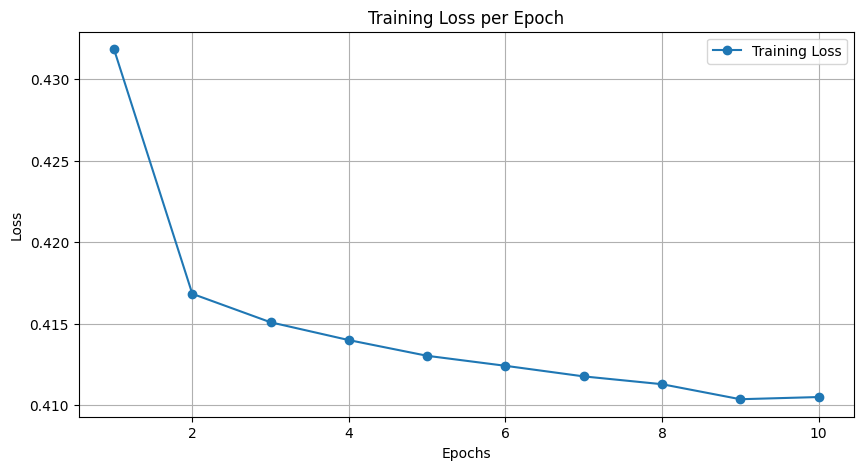

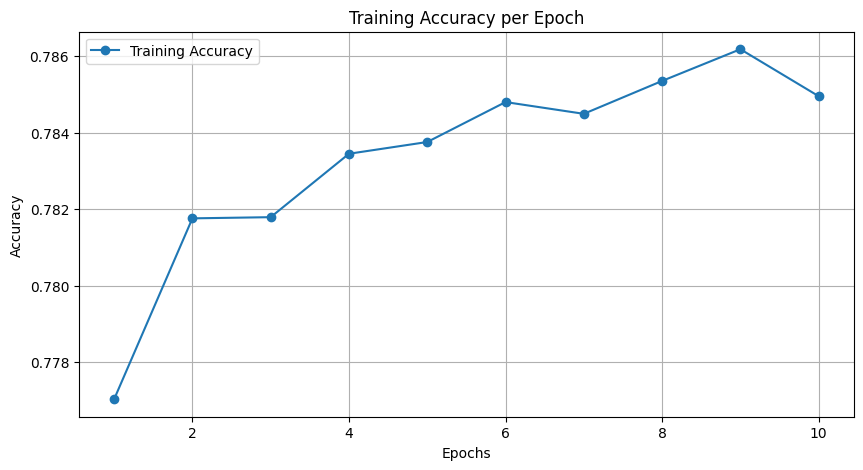

In [ ]:
import matplotlib.pyplot as plt

# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_loss, label='Training Loss', marker='o')
plt.title('Training Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

# Plot Accuracy
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_acc, label='Training Accuracy', marker='o')
plt.title('Training Accuracy per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()


# **Part 2 : Multi Class Classification:**

In [12]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# **Loading and preprocessing the Data:**

Downloading the data and spliting the training and test.

we choose to split the data to :  80% for training and 20% for validation.

In [13]:
# Define transformations for preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert images to PyTorch tensors
    transforms.Normalize((0.5,), (0.5,))  # Normalize pixel values to [-1, 1]
])

# Download and load the FashionMNIST dataset
train_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Split training data into training and validation sets
train_size = int(0.8 * len(train_data))  # 80% for training
val_size = len(train_data) - train_size  # 20% for validation
train_dataset, val_dataset = random_split(train_data, [train_size, val_size])


100%|██████████| 26.4M/26.4M [00:01<00:00, 18.0MB/s]


Extracting ./data/FashionMNIST/raw/train-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 301kB/s]


Extracting ./data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 4.42M/4.42M [00:00<00:00, 5.62MB/s]


Extracting ./data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 5.15k/5.15k [00:00<00:00, 15.6MB/s]


Extracting ./data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



**We will Create the Batch sizes in this Cell.**

In [14]:
# Create data loaders

from torch.utils.data import Subset

def filter_dataset(dataset, allowed_labels):
    indices = [i for i, (_, label) in enumerate(dataset) if label in allowed_labels]
    return Subset(dataset, indices)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)


# Filter training and validation datasets for Network 1 (first 4 categories)
allowed_labels = [0, 1, 2, 3]
train_dataset_1 = filter_dataset(train_dataset, allowed_labels)
val_dataset_1 = filter_dataset(val_dataset, allowed_labels)
test_dataset_1 = filter_dataset(test_data, allowed_labels)

# Create DataLoaders for Network 1
train_loader_1 = DataLoader(train_dataset_1, batch_size=batch_size, shuffle=True)
val_loader_1 = DataLoader(val_dataset_1, batch_size=batch_size, shuffle=False)
test_loader_1 = DataLoader(test_dataset_1, batch_size=batch_size, shuffle=False)






# **Defining the Model :**

## First Feed Forward Netwrok : Netwrok 1

The first network will be  2 layer network : input and output layers: <br>
input size= 784 (28X28) . <br>
output size = 4 .<br>
So, the Total parameters of the network will be (784X4) + 4 (bias)  parameters.

In [16]:

class Network1(nn.Module):
    def __init__(self):
        super(Network1, self).__init__()
        self.fc1 = nn.Linear(784,4)  # First layer: 784 → 4


    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten 28x28 images into 1D vector
        x = self.fc1(x)  # Output
        return x


# **Secound  Feed Forward Netwrok : Netwrok 2**

The secound network is a 4 layer netwrok:
Since, the netwrok parameters shouldnt pass 60k, we choose the network to be :<br>
input size= 784 since flatteing (28X28) img to vector.<br>
first layer : input (784) to output (60)<br>
second Layer: input (60) to output (40)<br>
third Layer : input (40) to output (10) .<br>
So, the Total  number of the netwrok parameters will be:
784* 60 + 60 + 60*40 + 40 + 40 *10 + 10 =49,550 <= 60K


In [17]:
class Network2(nn.Module):
    def __init__(self):
        super(Network2, self).__init__()
        self.fc1 = nn.Linear(784, 60)  # First layer: 784 → 60
        self.fc2 = nn.Linear(60, 40)  # Second layer: 60 → 40
        self.fc3 = nn.Linear(40, 10)  # Third layer: 40 → 10


    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten 28x28 images into 1D vector
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)  # Output
        return x


**Now we traing the model **

In [18]:
def train_model(model, train_loader, val_loader, optimizer, criterion, epochs):
    # Store metrics
    train_loss = []
    val_loss = []
    train_acc = []
    val_acc = []

    for epoch in range(epochs):
        # Training phase
        model.train()
        correct_train = 0
        total_train = 0
        running_loss = 0.0

        for images, labels in train_loader:
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Update training metrics
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

        train_loss.append(running_loss / len(train_loader))
        train_acc.append(correct_train / total_train)

        # Validation phase
        model.eval()
        correct_val = 0
        total_val = 0
        val_running_loss = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                correct_val += (predicted == labels).sum().item()
                total_val += labels.size(0)

        val_loss.append(val_running_loss / len(val_loader))
        val_acc.append(correct_val / total_val)

        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss[-1]:.4f}, Train Acc: {train_acc[-1]*100:.2f}%, "
              f"Val Loss: {val_loss[-1]:.4f}, Val Acc: {val_acc[-1]*100:.2f}%")

    return train_loss, val_loss, train_acc, val_acc



In [19]:
# Instantiate models
model1 = Network1()  # Network 1 for 4 categories
model2 = Network2()  # Network 2 for all 10 categories

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer1 = torch.optim.Adam(model1.parameters(), lr=0.001, weight_decay=1e-4)  # With L2 regularization
optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.001, weight_decay=1e-4)

# Training parameters
epochs = 20

# Train both networks
print("Training Network 1:")
train_loss1, val_loss1, train_acc1, val_acc1 = train_model(model1, train_loader_1, val_loader_1, optimizer1, criterion, epochs)

print("\nTraining Network 2:")
train_loss2, val_loss2, train_acc2, val_acc2 = train_model(model2, train_loader, val_loader, optimizer2, criterion, epochs)


Training Network 1:
Epoch 1/20, Train Loss: 0.3122, Train Acc: 90.22%, Val Loss: 0.2459, Val Acc: 91.91%
Epoch 2/20, Train Loss: 0.2199, Train Acc: 92.83%, Val Loss: 0.2152, Val Acc: 93.14%
Epoch 3/20, Train Loss: 0.2106, Train Acc: 93.20%, Val Loss: 0.2095, Val Acc: 93.45%
Epoch 4/20, Train Loss: 0.1990, Train Acc: 93.56%, Val Loss: 0.2158, Val Acc: 92.72%
Epoch 5/20, Train Loss: 0.1964, Train Acc: 93.61%, Val Loss: 0.2049, Val Acc: 93.55%
Epoch 6/20, Train Loss: 0.1907, Train Acc: 93.93%, Val Loss: 0.2052, Val Acc: 93.07%
Epoch 7/20, Train Loss: 0.1875, Train Acc: 94.01%, Val Loss: 0.1984, Val Acc: 93.67%
Epoch 8/20, Train Loss: 0.1894, Train Acc: 93.74%, Val Loss: 0.1921, Val Acc: 93.65%
Epoch 9/20, Train Loss: 0.1835, Train Acc: 94.07%, Val Loss: 0.1898, Val Acc: 93.72%
Epoch 10/20, Train Loss: 0.1810, Train Acc: 94.13%, Val Loss: 0.1924, Val Acc: 94.01%
Epoch 11/20, Train Loss: 0.1800, Train Acc: 94.09%, Val Loss: 0.1932, Val Acc: 93.82%
Epoch 12/20, Train Loss: 0.1771, Train Acc:

In [20]:
def evaluate_model(model, loader, criterion):
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0

    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    return running_loss / len(loader), accuracy



In [21]:
# Evaluate Network 1
test_loss1, test_acc1 = evaluate_model(model1, test_loader_1, criterion)
print(f"Network 1 - Test Loss: {test_loss1:.4f}, Test Accuracy: {test_acc1 * 100:.2f}%")

# Evaluate Network 2
test_loss2, test_acc2 = evaluate_model(model2, test_loader, criterion)
print(f"Network 2 - Test Loss: {test_loss2:.4f}, Test Accuracy: {test_acc2 * 100:.2f}%")


Network 1 - Test Loss: 0.2225, Test Accuracy: 92.85%
Network 2 - Test Loss: 0.3910, Test Accuracy: 87.10%


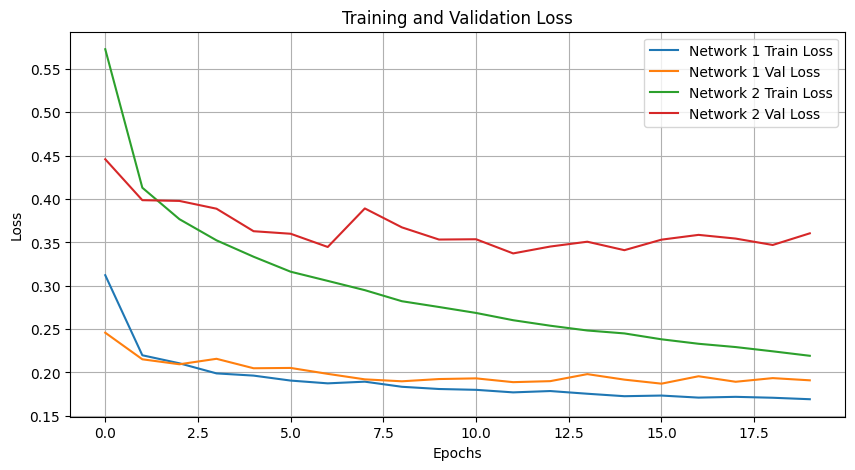

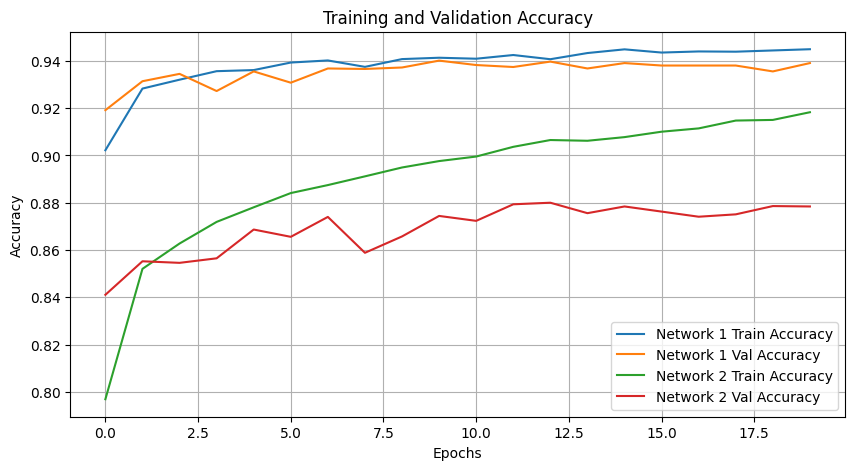

In [22]:
import matplotlib.pyplot as plt

# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(train_loss1, label='Network 1 Train Loss')
plt.plot(val_loss1, label='Network 1 Val Loss')
plt.plot(train_loss2, label='Network 2 Train Loss')
plt.plot(val_loss2, label='Network 2 Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

# Plot Accuracy
plt.figure(figsize=(10, 5))
plt.plot(train_acc1, label='Network 1 Train Accuracy')
plt.plot(val_acc1, label='Network 1 Val Accuracy')
plt.plot(train_acc2, label='Network 2 Train Accuracy')
plt.plot(val_acc2, label='Network 2 Val Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()
